# SSD 条带位置模型：独立加载、预测与误差评估

**功能**：从 `SSD/EnergyLoss_output/EnergyLossMLP.pt` 加载完整 SSD 条带位置模型，对 `SSD/Processd_test.root/tree` 预测 alpha 顶点总动能并评估误差。

**方法**：加载模型及特征顺序、训练集归一化参数 → uproot / awkward 读取标量分支 → NumPy float64 → 输入归一化 → PyTorch float64 推理 → 输出反归一化（MeV）→ 残差和能量和基线对比。

**注意事项**：先调用 `PreProcess.C` 顺序生成 `Processd.root` 和 `Processd_test.root`，再执行训练 Notebook，用 `Processd.root` 训练并保存模型，最后执行本 Notebook，对 `Processd_test.root` 预测。条带世界坐标单位 mm，顶点仍是模拟真值；测试文件应来自独立于训练文件的模拟事件。预测复用训练统计量，不重建或训练网络。完整模型使用 `weights_only=False` 加载，仅加载自己生成的可信模型。所有输出只使用 SSD 内路径，原 EnergyLoss 模型和 ROOT 文件不参与本流程。

依赖：`uproot`、`awkward`、`numpy`、`torch`、`matplotlib`。CUDA 可用时使用 CUDA，否则使用 CPU，保持 float64。本文件交付时未执行任何单元。结构沿用用户指定的原 `EnergyLossEvaluation.ipynb` 和 machine-learning 技能的保存/加载流程。

## 1. 输入及运行设备


In [1]:
# 功能：配置 SSD 模型预测；方法：统一路径与 float64；注意事项：从 EnergyLoss 或 SSD 目录启动。
from pathlib import Path

import awkward as ak
import numpy as np
import torch
import uproot
import matplotlib.pyplot as plt

SSD_DIR = Path.cwd() if Path.cwd().name == "SSD" else Path.cwd() / "SSD"
ROOT_PATH = SSD_DIR / "Processd_test.root"
TREE_NAME = "tree"
MODEL_PATH = SSD_DIR / "EnergyLoss_output" / "EnergyLossMLP.pt"
TARGET_NAME = "KinematicsAtVertex"
DTYPE = torch.float64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [2]:
saved = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
if saved.get("position_source") != "SSD_strip_world":
    raise ValueError("请选择 SSD 条带位置训练流程保存的模型，不能混用真实击中位置模型。")

model = saved["model"].to(device=device, dtype=DTYPE)
model.eval()

FEATURE_NAMES = saved["feature_names"]
x_mean = np.asarray(saved["x_mean"], dtype=np.float64)
x_std = np.asarray(saved["x_std"], dtype=np.float64)
y_mean = np.asarray(saved["y_mean"], dtype=np.float64)
y_std = np.asarray(saved["y_std"], dtype=np.float64)

print(model)
print("Loaded:", MODEL_PATH.resolve())
if x_mean.shape != (len(FEATURE_NAMES),) or x_std.shape != x_mean.shape:
    raise ValueError("保存的输入归一化参数与特征数不匹配。")
if y_mean.shape != (1,) or y_std.shape != (1,):
    raise ValueError("保存的标签归一化参数须对应一个输出。")
if any(not np.all(np.isfinite(a)) for a in (x_mean, x_std, y_mean, y_std)):
    raise ValueError("模型归一化参数含 NaN/Inf。")
if np.any(x_std <= 0) or np.any(y_std <= 0):
    raise ValueError("模型归一化缩放量须大于 0。")


Sequential(
  (0): Linear(in_features=13, out_features=64, bias=True)
  (1): Tanh()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Tanh()
  (4): Linear(in_features=64, out_features=64, bias=True)
  (5): Tanh()
  (6): Linear(in_features=64, out_features=1, bias=True)
)
Loaded: /Users/yemingxin/ROOT_Exercise/MachineLearning/EnergyLoss/SSD/EnergyLoss_output/EnergyLossMLP.pt


In [3]:
branches = FEATURE_NAMES + [TARGET_NAME]
with uproot.open(ROOT_PATH) as root_file:
    tree = root_file[TREE_NAME]
    missing = [name for name in branches if name not in tree.keys()]
    if missing:
        raise KeyError(f"Missing branches: {missing}")
    entry_count = tree.num_entries
    arrays = tree.arrays(branches, library="ak", how=dict)

columns = {}
for name in branches:
    column = np.asarray(ak.to_numpy(arrays[name]), dtype=np.float64)
    if column.ndim != 1 or len(column) != entry_count:
        raise ValueError(f"{name} 必须是每事件一个标量，实际 shape={column.shape}")
    if np.any(~np.isfinite(column) | (column == -999.0)):
        raise ValueError(f"{name} contains NaN/Inf or -999.")
    columns[name] = column
X = np.column_stack([columns[name] for name in FEATURE_NAMES]).astype(np.float64)
y = columns[TARGET_NAME].reshape(-1, 1)
if entry_count == 0:
    raise ValueError("测试树没有事件。")
if np.any(columns["ClusterGAGGEnergy"] <= 0) or np.any(columns["DeltaEGAGGEnergy"] < 0) or np.any(y <= 0):
    raise ValueError("主 GAGG 与标签须大于 0，DeltaE 能量须大于等于 0。")
print("X:", X.shape, X.dtype)
print("y:", y.shape, y.dtype)


X: (8049, 13) float64
y: (8049, 1) float64


## 2. 使用保存的参数归一化并预测
`model.eval()` 与 `torch.no_grad()` 下直接调用加载的完整模型，再用保存的 `y_std`、`y_mean` 将输出恢复为 MeV。残差定义为预测 − 真值。


In [4]:
X_scaled = (X - x_mean) / x_std
X_tensor = torch.from_numpy(X_scaled).to(device=device, dtype=DTYPE)

model.eval()
with torch.no_grad():
    pred_scaled = model(X_tensor).cpu().numpy()

pred = pred_scaled * y_std + y_mean
if not np.all(np.isfinite(pred)):
    raise RuntimeError("模型预测包含 NaN/Inf。")
residual = pred - y

print("Predicted events:", len(pred))
print("entry     truth (MeV)    prediction (MeV)    residual (MeV)")
for i in range(min(10, len(pred))):
    print(f"{i:5d} {y[i, 0]:15.6f} {pred[i, 0]:19.6f} {residual[i, 0]:17.6f}")


Predicted events: 8049
entry     truth (MeV)    prediction (MeV)    residual (MeV)
    0      669.037506          670.442959          1.405453
    1      643.762447          643.436586         -0.325861
    2      621.652195          621.352389         -0.299806
    3      699.193099          700.028087          0.834988
    4      717.536648          716.541653         -0.994995
    5      741.456012          741.606964          0.150952
    6      767.782876          767.171084         -0.611792
    7      716.331747          715.294187         -1.037560
    8      741.706147          743.374344          1.668197
    9      640.785042          638.884129         -1.900913


Test events: 8049
MSE_MeV2             MLP=2.21037  energy-sum baseline=895.352
RMSE_MeV             MLP=1.48673  energy-sum baseline=29.9224
MAE_MeV              MLP=1.14011  energy-sum baseline=22.9022
R2                   MLP=0.998535  energy-sum baseline=0.406447
Bias_MeV             MLP=0.00251453  energy-sum baseline=-22.8915
ResidualStd_MeV      MLP=1.48673  energy-sum baseline=19.27


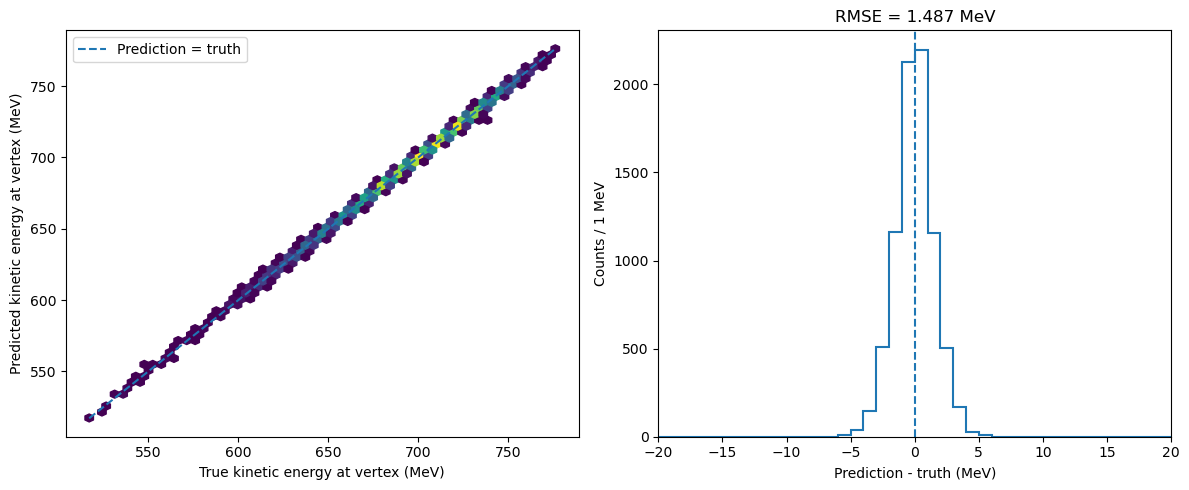

In [5]:
def regression_metrics(truth, prediction):
    difference = prediction - truth
    mse = float(np.mean(difference ** 2))
    ss_tot = float(np.sum((truth - truth.mean()) ** 2))
    r2 = 1.0 - float(np.sum(difference ** 2)) / ss_tot if ss_tot > 0 else np.nan

    return {
        "MSE_MeV2": mse,
        "RMSE_MeV": float(np.sqrt(mse)),
        "MAE_MeV": float(np.mean(np.abs(difference))),
        "R2": r2,
        "Bias_MeV": float(difference.mean()),
        "ResidualStd_MeV": float(difference.std()),
    }

metrics = regression_metrics(y, pred)
energy_sum = (columns["ClusterGAGGEnergy"] + columns["DeltaEGAGGEnergy"]).reshape(-1, 1)
baseline_metrics = regression_metrics(y, energy_sum)

print(f"Test events: {len(y)}")
for name in metrics:
    print(f"{name:20s} MLP={metrics[name]:.6g}  energy-sum baseline={baseline_metrics[name]:.6g}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hexbin(y[:, 0], pred[:, 0], gridsize=55, mincnt=1)
lo = min(y.min(), pred.min())
hi = max(y.max(), pred.max())
axes[0].plot([lo, hi], [lo, hi], "--", label="Prediction = truth")
axes[0].set_xlabel("True kinetic energy at vertex (MeV)")
axes[0].set_ylabel("Predicted kinetic energy at vertex (MeV)")
axes[0].legend()

bins = np.arange(-20.0, 21.0, 1.0)
_, bin_edges, _ = axes[1].hist(residual[:, 0], bins=bins, histtype="step", linewidth=1.5)
axes[1].axvline(0.0, linestyle="--")
axes[1].set_xlim(-20, 20)
axes[1].set_xlabel("Prediction - truth (MeV)")
axes[1].set_ylabel(f"Counts / {bin_edges[1] - bin_edges[0]:.3g} MeV")
axes[1].set_title(f"RMSE = {metrics['RMSE_MeV']:.3f} MeV")

fig.tight_layout()
plt.show()
